In [1]:
import time
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import seaborn as sns
import sys
import struct
from scipy import interpolate

In [2]:
# Para rodar no colab
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
shot_size = (640,128) #tamanho dos tiros
img_size = (128,128) #tamanho das imagens
n_filters = 12 #número de tiros

In [3]:
data_dir ='../GeracaoTiros/TirosMods1/'
mod_dir = '../GeracaoModelosVel/Mods1/Bin/'
# LOADING PATHS
shot_list = [xn for xn in os.listdir(data_dir) if "shot" in xn]
mod_list = [xn for xn in os.listdir(mod_dir) if "model" in xn]
mod_list.sort()
shot_list.sort()

# LOADING IMAGES


x_data = np.zeros((len(shot_list), n_filters) + img_size)
y_data = np.zeros( (len(shot_list), )+img_size)
for i in range(len(shot_list)):
    ent=np.load(data_dir + shot_list[i])
    sai=np.load(mod_dir + mod_list[i])
#    ent.shape
    x_data[i,:,:,:] = np.transpose(ent[:,:,0:640:5],(0,2,1)) 
    y_data[i,:,:] = sai[:,:]

In [4]:
def normalize_function(img):
    imag = img
    vis_p_max = np.percentile(imag, 96)
    vis_p_min = -np.percentile(imag, 96)
    clip=(vis_p_max - vis_p_min)/2
    imag = np.clip(imag,-clip,clip)
    imag=(imag+clip)/(2*clip)
    return imag

In [5]:
for filt in range(n_filters):
    x_data[:, filt,:, :] = normalize_function(x_data[:, filt,:, :])
y_data=y_data/1000 # trata a velocidade como km/s, range de saída menor

In [7]:
np.amin(y_data)

np.float64(1.00798)

In [6]:
y_datan=(y_data-np.amin(y_data))
y_data=y_datan/np.amax(y_datan)

In [9]:
np.amin(y_datan)

np.float64(0.0)

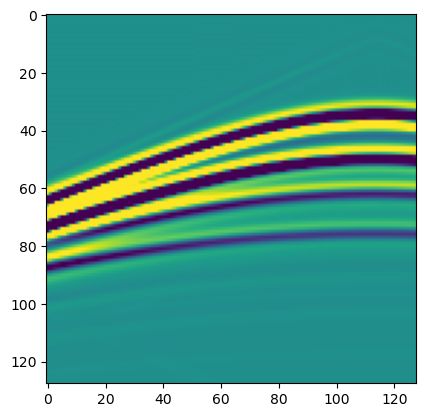

In [7]:
plt.imshow(x_data[20, 11, :, :])

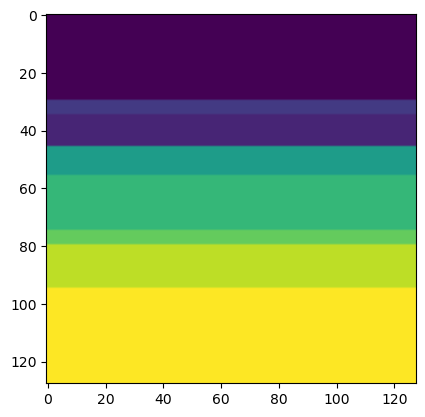

In [8]:
plt.imshow(y_data[10, :, :])

In [12]:
np.amax(y_data)

np.float64(1.0)

In [9]:
import torch
import torch.nn as nn
from pytorch_msssim import ssim
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torch.optim import Adam

In [ ]:
EPOCAS=150
BATCH = 8
PATIENCE = 25

In [14]:
class Conv2dBlock(nn.Module):
    def __init__(self, in_channels, out_channels,
                 kernel_size=3,
                 batchnorm=True,
                 momentum=0.9):
        super().__init__()
        layers = []
        layers.append(
            nn.Conv2d(in_channels,out_channels,kernel_size=kernel_size,padding="same",bias=not batchnorm)
        )

        if batchnorm:
            layers.append(
                nn.BatchNorm2d(out_channels,momentum=1 - momentum)
            )

        layers.append(nn.ReLU(inplace=True))
        layers.append(
            nn.Conv2d(out_channels,out_channels,kernel_size=kernel_size,padding="same",bias=not batchnorm)
        )
        if batchnorm:
            layers.append(
                nn.BatchNorm2d(out_channels,momentum=0.1)
            )

        layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [15]:
class UNetUpConv(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        self.up6 = nn.ConvTranspose2d(n_filters * 16,n_filters * 16,kernel_size=3,stride=2, padding=1,output_padding=1)

        self.up7 = nn.ConvTranspose2d(n_filters * 8,n_filters * 8,kernel_size=3,stride=2,padding=1,output_padding=1)

        self.up8 = nn.ConvTranspose2d(n_filters * 4,n_filters * 4,kernel_size=3,stride=2,padding=1,output_padding=1)

        self.up9 = nn.ConvTranspose2d(n_filters * 2,n_filters*2,kernel_size=3,stride=2,padding=1,output_padding=1)

        self.c6 = Conv2dBlock(n_filters * 16+n_filters * 8,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8+n_filters * 4,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4+n_filters * 2,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2+n_filters,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        return self.out(c9)

In [16]:
class UNetUp(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        self.up6 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up7 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up8 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up9 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.c6 = Conv2dBlock(n_filters * 16+n_filters * 8,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8+n_filters * 4,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4+n_filters * 2,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2+n_filters,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment)
        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        return self.out(c9)

In [17]:
class UNetModUp(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        self.up6 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up7 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up8 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up9 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.c6 = Conv2dBlock(n_filters * 16+n_filters * 8,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8+n_filters * 4,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4+n_filters * 2,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment)
        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        #u9 = torch.cat([u9, c1], dim=1)
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        return self.out(c9)

In [18]:
class EncDecSig(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        self.up6 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up7 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up8 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up9 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.c6 = Conv2dBlock(n_filters * 16,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment)
        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        #u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        #u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        #u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        #u9 = torch.cat([u9, c1], dim=1)
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        return torch.sigmoid(self.out(c9))   

In [19]:
class SSIM(nn.Module):
    def __init__(self):
        super().__init__()
    coef = 0.5
    def forward(self,y_true, y_pred):
        loss = 1 - ssim(y_pred,y_true,data_range=1.0,size_average=True,win_size=3)
        return loss

In [20]:
class SSIMLossRMSE(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self,y_true, y_pred):
        ssim_term = 1 - ssim(y_pred,y_true,data_range=1.0,size_average=True,win_size=3)
        l2 = torch.sum((y_true - y_pred) ** 2,dim=1)
        loss =  ssim_term + l2.mean()
        return loss

In [22]:
img_train, x_test, mask_train, y_test = train_test_split( x_data,np.expand_dims(y_data, axis=1),test_size=0.1,random_state=42)
x_train, x_val, y_train, y_val = train_test_split(img_train,mask_train,test_size=1/8,random_state=42)

In [23]:
class ImageDataset(Dataset):
    def __init__(self, images, masks):
        self.images = torch.tensor(images,dtype=torch.float32)
        self.masks = torch.tensor(masks,dtype=torch.float32)
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]

In [24]:
train_dataset = ImageDataset(x_train,y_train)
val_dataset = ImageDataset(x_val,y_val)
train_loader = DataLoader(train_dataset,batch_size=BATCH,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=BATCH,shuffle=False)

In [25]:
model = EncDecSig(in_channels=n_filters, n_filters=16,dropout=0.2,moment=0.2,batchnorm=True)
from torchsummary import summary
summary(model,input_size=(12, 128, 128), device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 128]           4,800
       BatchNorm2d-2         [-1, 16, 128, 128]              32
              ReLU-3         [-1, 16, 128, 128]               0
            Conv2d-4         [-1, 16, 128, 128]           6,400
       BatchNorm2d-5         [-1, 16, 128, 128]              32
              ReLU-6         [-1, 16, 128, 128]               0
       Conv2dBlock-7         [-1, 16, 128, 128]               0
         MaxPool2d-8           [-1, 16, 64, 64]               0
         Dropout2d-9           [-1, 16, 64, 64]               0
           Conv2d-10           [-1, 32, 64, 64]          12,800
      BatchNorm2d-11           [-1, 32, 64, 64]              64
             ReLU-12           [-1, 32, 64, 64]               0
           Conv2d-13           [-1, 32, 64, 64]          25,600
      BatchNorm2d-14           [-1, 32,

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
#criterion = nn.MSELoss()
criterion= SSIMLossRMSE()
optimizer = Adam(model.parameters(),lr=1e-4,weight_decay=2e-4)
best_val_loss = float("inf")

counter = 0
train_losses = []
val_losses = []
train_maes = []
val_maes = []
for epoch in range(EPOCAS):
    # ======================
    # TREINO
    # ======================
    model.train()
    running_loss = 0.0
    running_mae = 0.0
    for images, targets in train_loader:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        mae = torch.mean(torch.abs(outputs - targets))
        running_loss += loss.item()
        running_mae += mae.item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_mae = running_mae / len(train_loader)
    # ======================
    # VALIDAÇÃO
    # ======================
    model.eval()
    running_val_loss = 0.0
    running_val_mae = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            mae = torch.mean(torch.abs(outputs - targets))
            running_val_loss += loss.item()
            running_val_mae += mae.item()
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_mae = running_val_mae / len(val_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_maes.append(epoch_train_mae)
    val_maes.append(epoch_val_mae)

    print(
        f"Epoch [{epoch+1}/{EPOCAS}] "
        f"loss={epoch_train_loss:.4f} "
        f"mae={epoch_train_mae:.4f} "
        f"val_loss={epoch_val_loss:.4f} "
        f"val_mae={epoch_val_mae:.4f}"
    )

    # ======================
    # MODEL CHECKPOINT
    # ======================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"model_teste01.pth")
        print(f"Val loss melhorou para {best_val_loss:.6f}. "f"Salvando modelo.")
        counter = 0
    else:
        counter += 1

        print(f"Val loss não melhorou. "f"Patience {counter}/{PATIENCE}")

        # ======================
        # EARLY STOPPING
        # ======================
        if counter >= PATIENCE:

            print("Early stopping!")
            break

Epoch [1/100] loss=0.2467 mae=0.2067 val_loss=0.1806 val_mae=0.1588
Val loss melhorou para 0.180579. Salvando modelo.
Epoch [2/100] loss=0.1678 mae=0.1466 val_loss=0.1431 val_mae=0.1138
Val loss melhorou para 0.143145. Salvando modelo.
Epoch [3/100] loss=0.1526 mae=0.1313 val_loss=0.1752 val_mae=0.1580
Val loss não melhorou. Patience 1/10
Epoch [4/100] loss=0.1439 mae=0.1223 val_loss=0.1378 val_mae=0.1121
Val loss melhorou para 0.137799. Salvando modelo.
Epoch [5/100] loss=0.1390 mae=0.1157 val_loss=0.1317 val_mae=0.1051
Val loss melhorou para 0.131706. Salvando modelo.
Epoch [6/100] loss=0.1340 mae=0.1100 val_loss=0.1279 val_mae=0.0963
Val loss melhorou para 0.127854. Salvando modelo.
Epoch [7/100] loss=0.1316 mae=0.1069 val_loss=0.1263 val_mae=0.0976
Val loss melhorou para 0.126329. Salvando modelo.
Epoch [8/100] loss=0.1276 mae=0.1012 val_loss=0.1223 val_mae=0.0837
Val loss melhorou para 0.122268. Salvando modelo.
Epoch [9/100] loss=0.1259 mae=0.0989 val_loss=0.1199 val_mae=0.0828
V

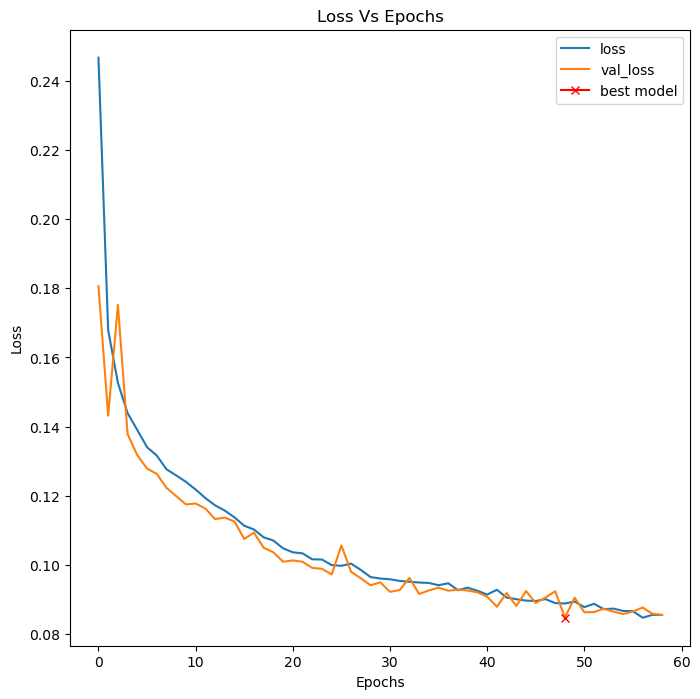

In [27]:
plt.figure(figsize=(8,8))
plt.title("Loss Vs Epochs")
plt.plot(train_losses, label="loss")
plt.plot(val_losses, label="val_loss")
plt.plot( np.argmin(val_losses), np.min(val_losses), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

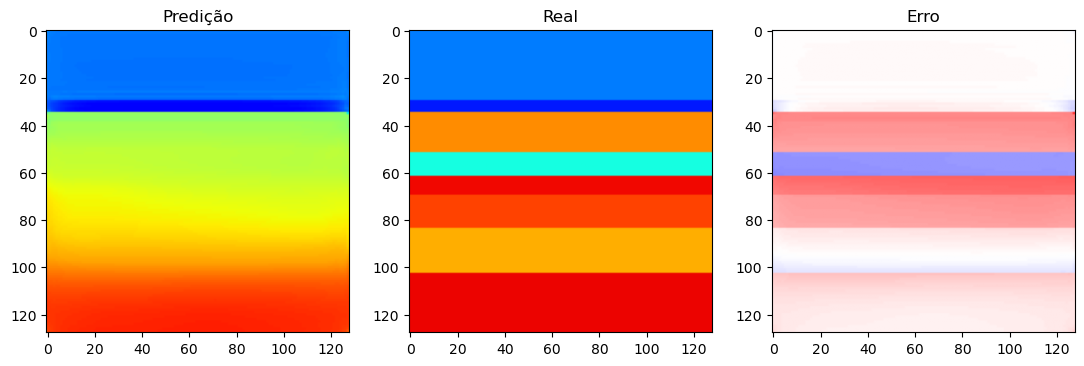

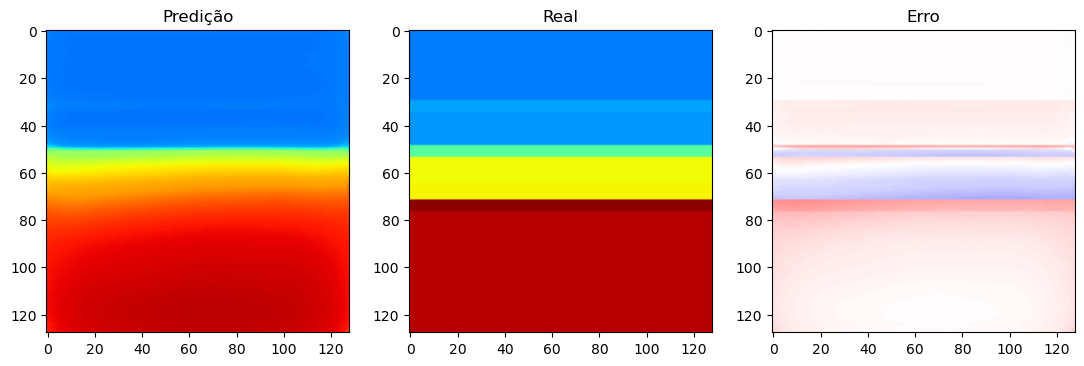

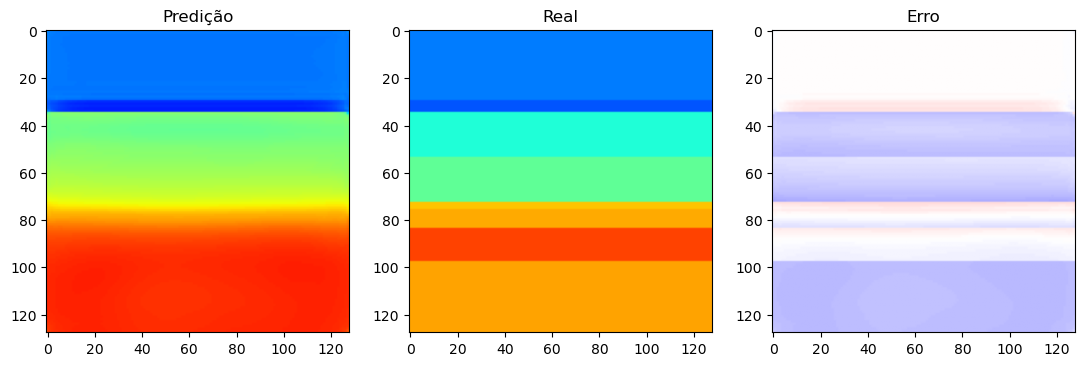

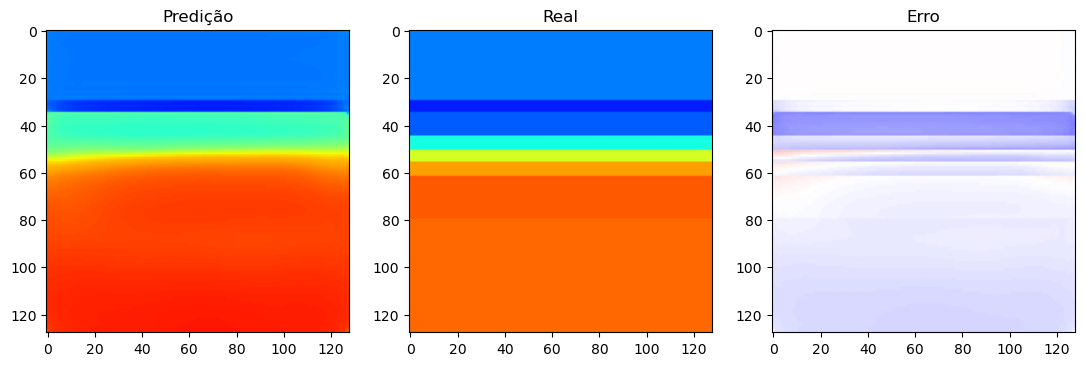

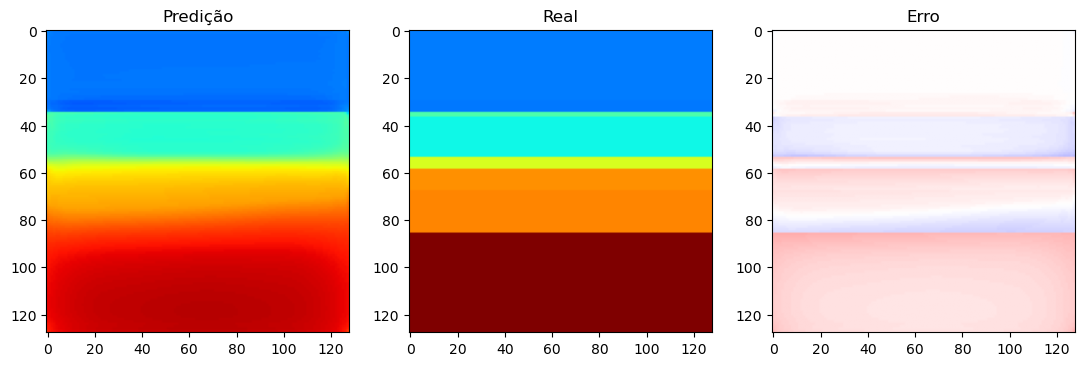

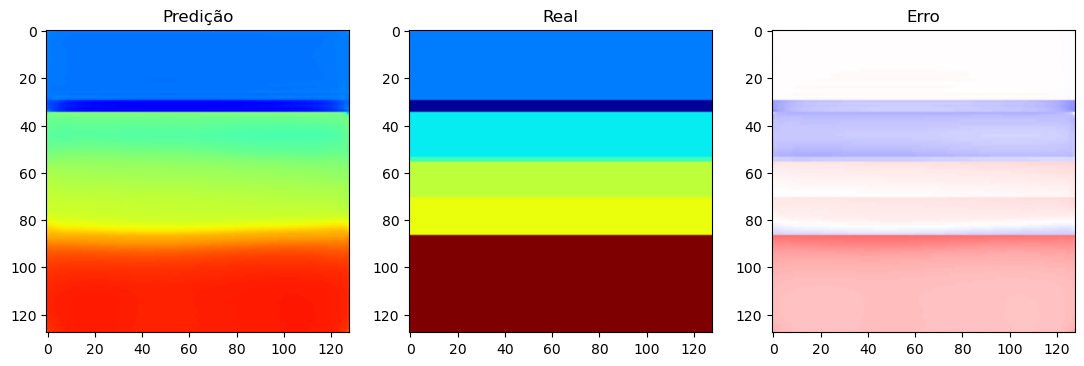

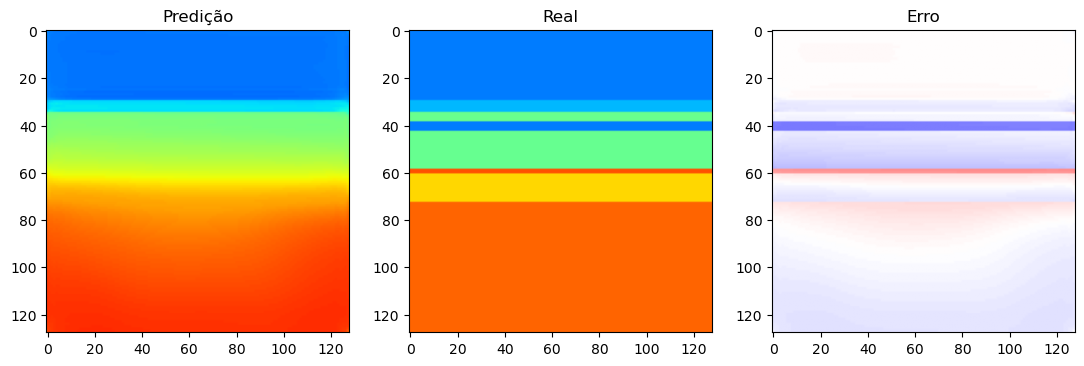

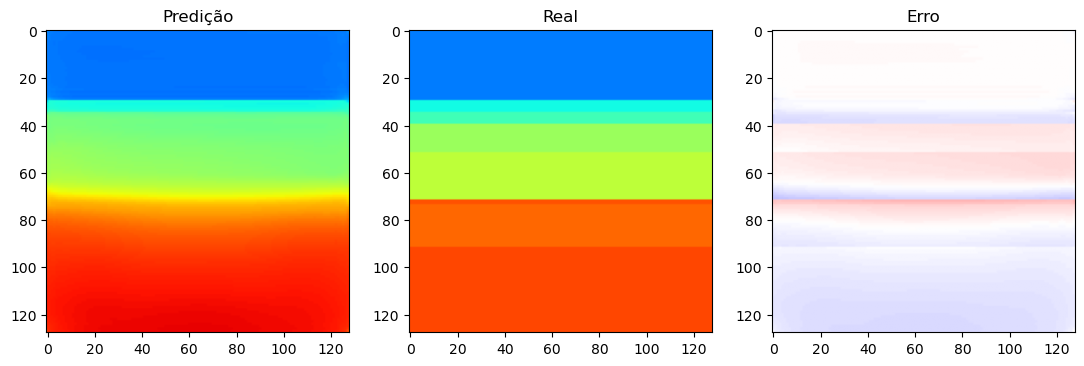

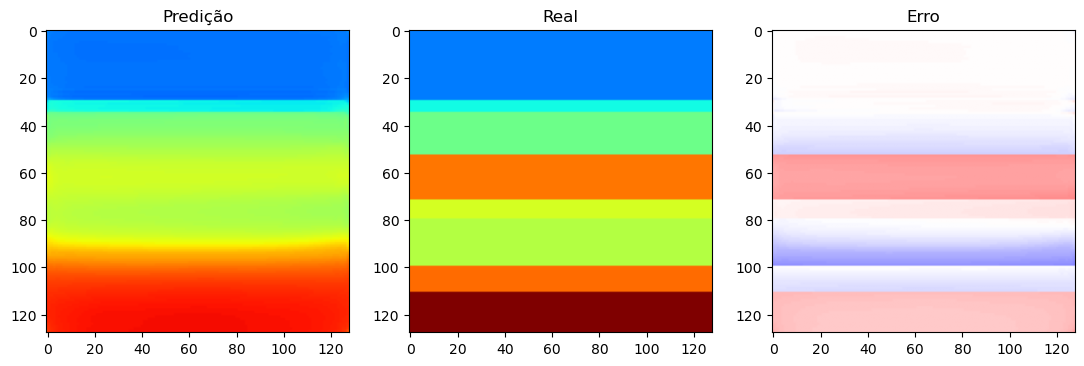

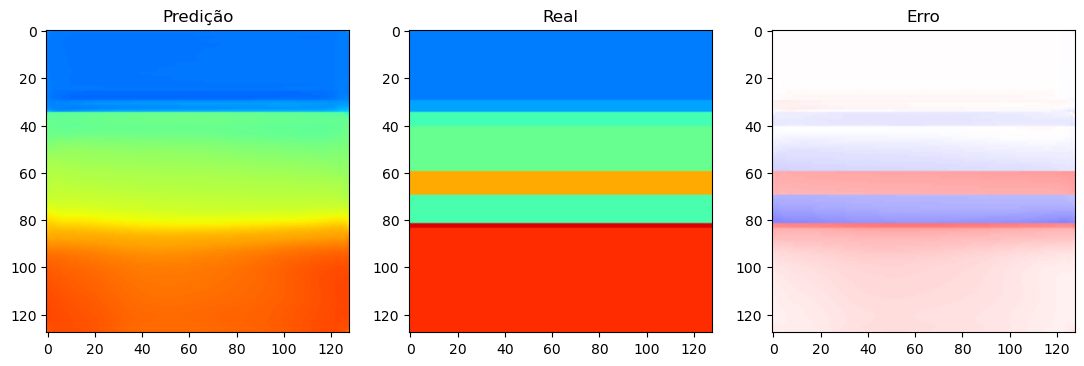

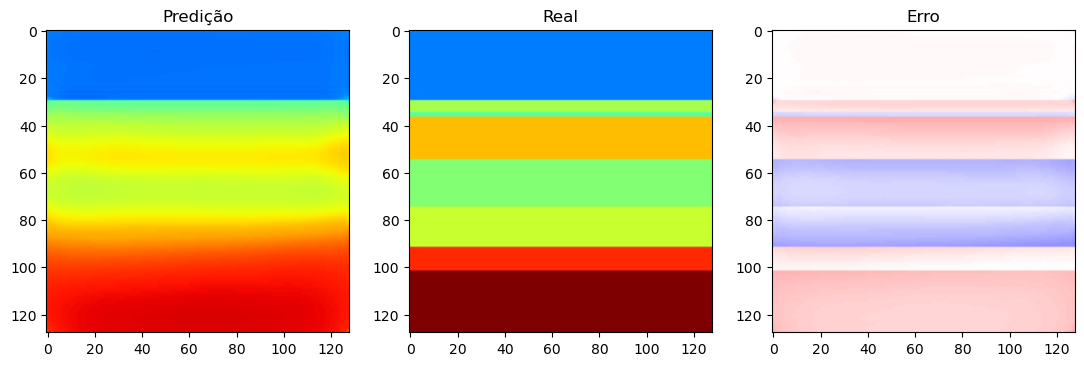

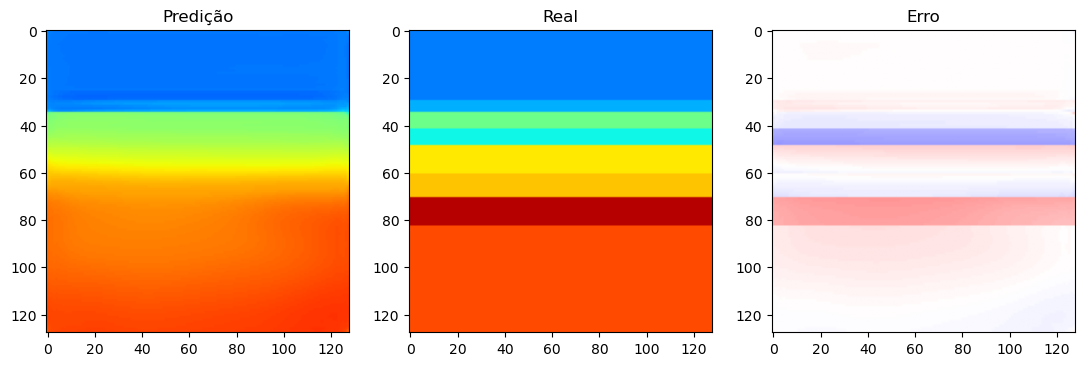

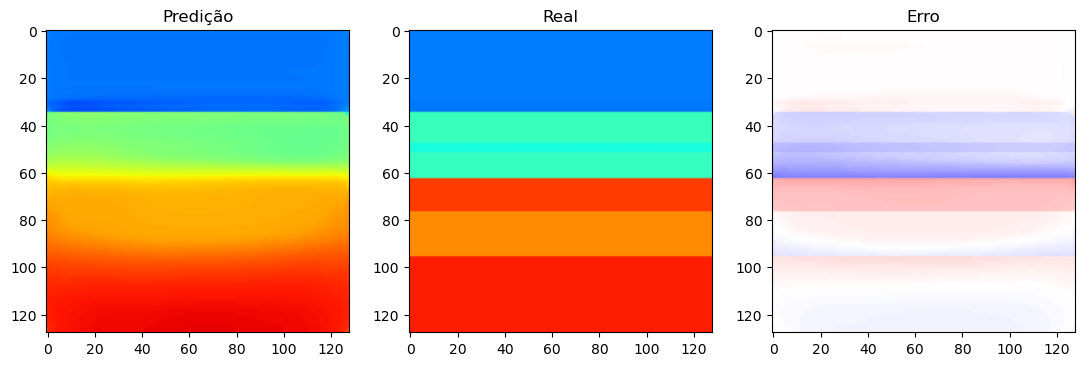

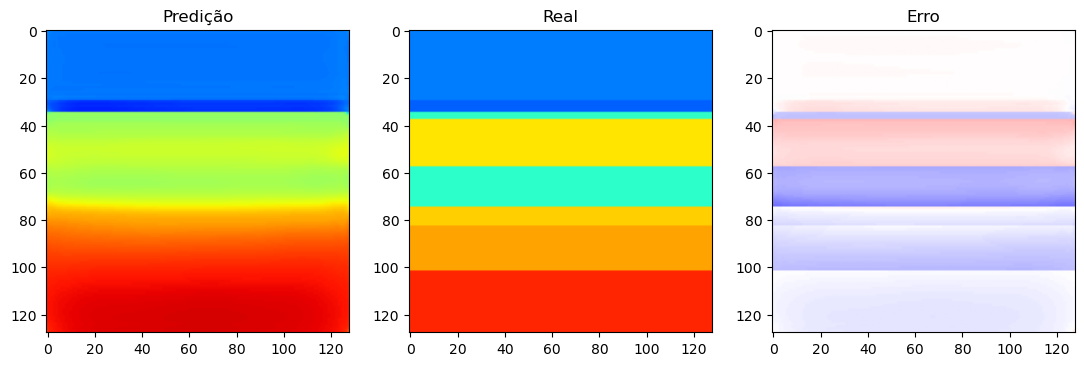

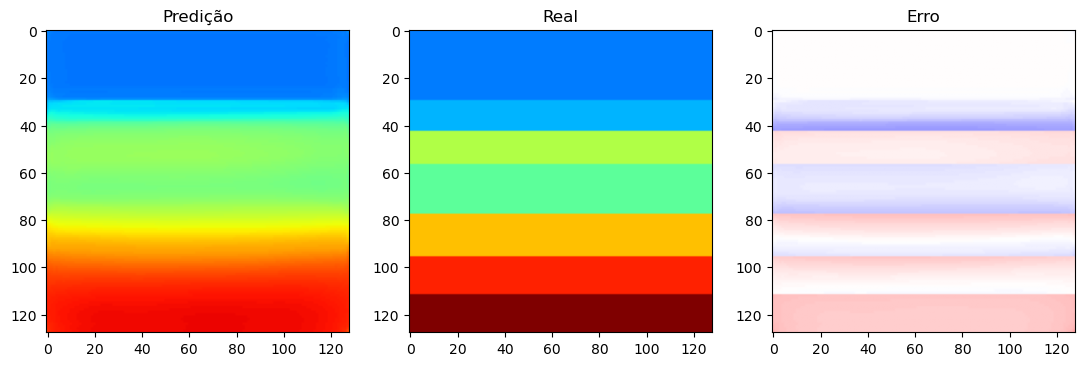

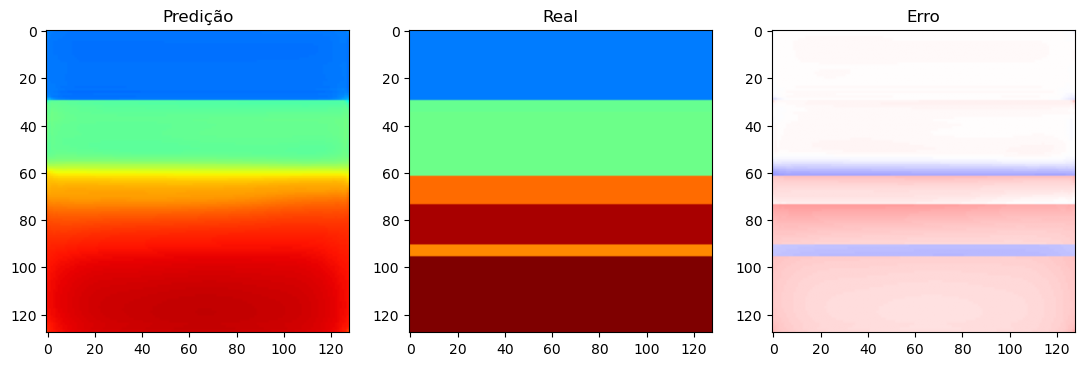

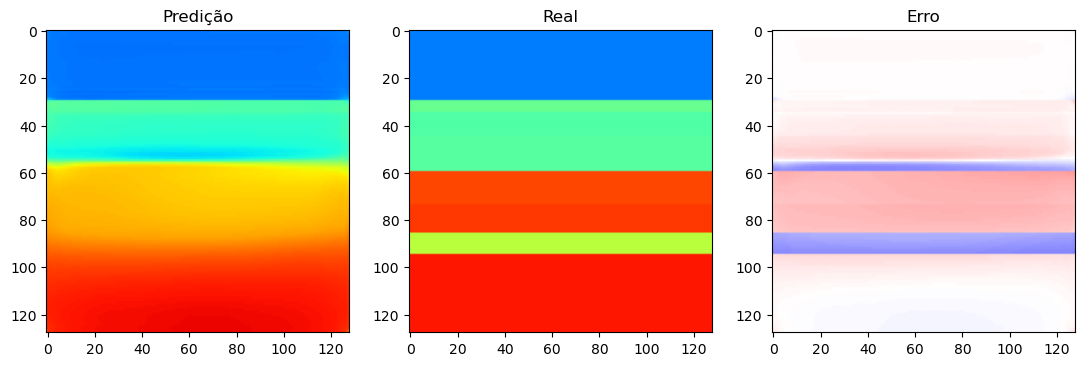

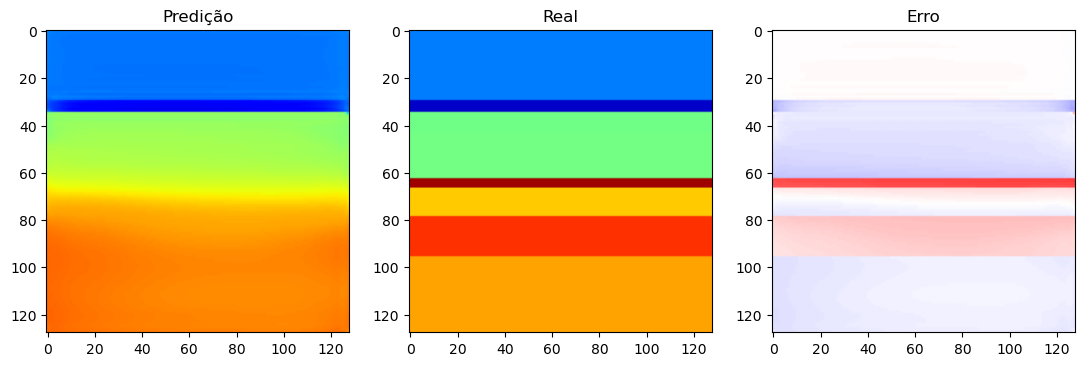

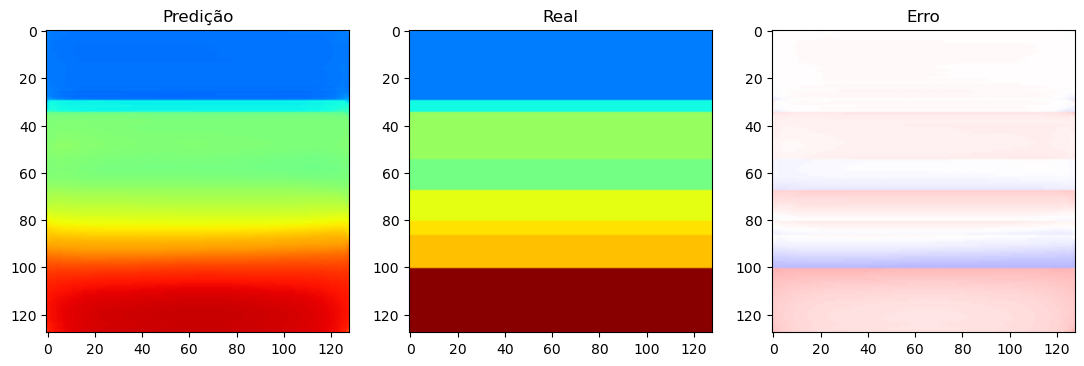

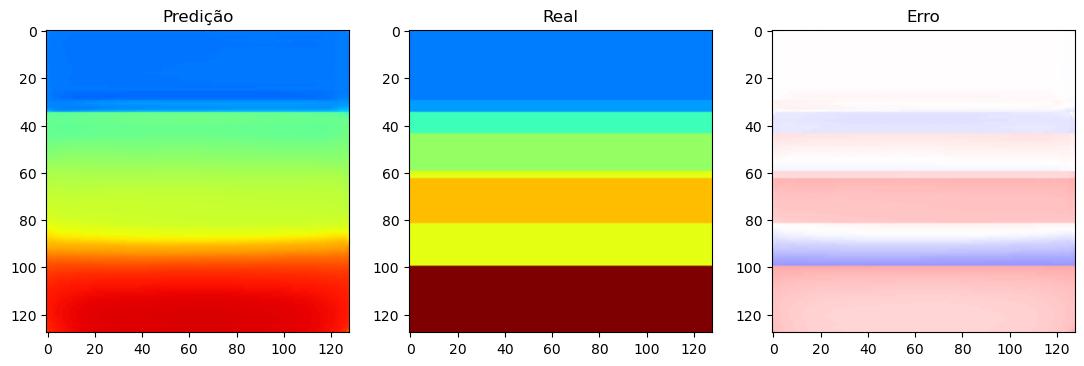

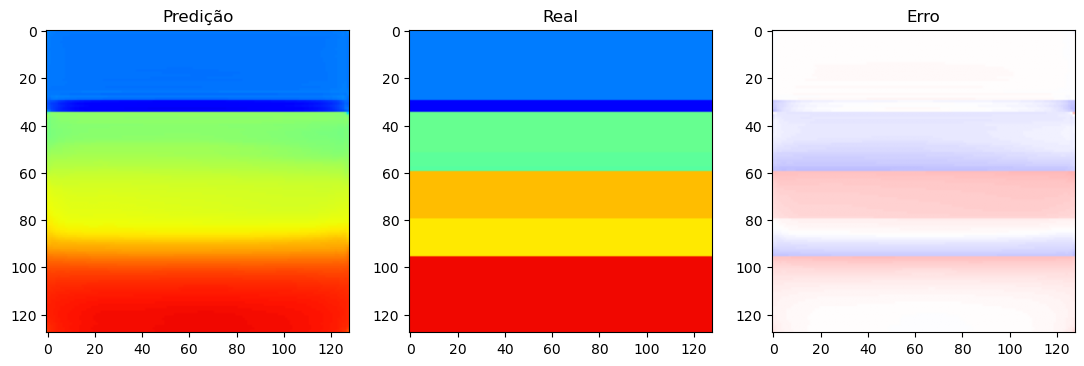

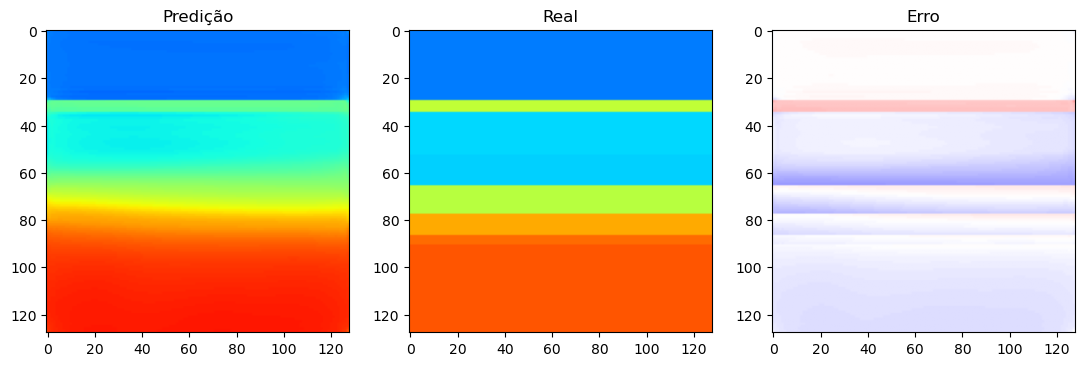

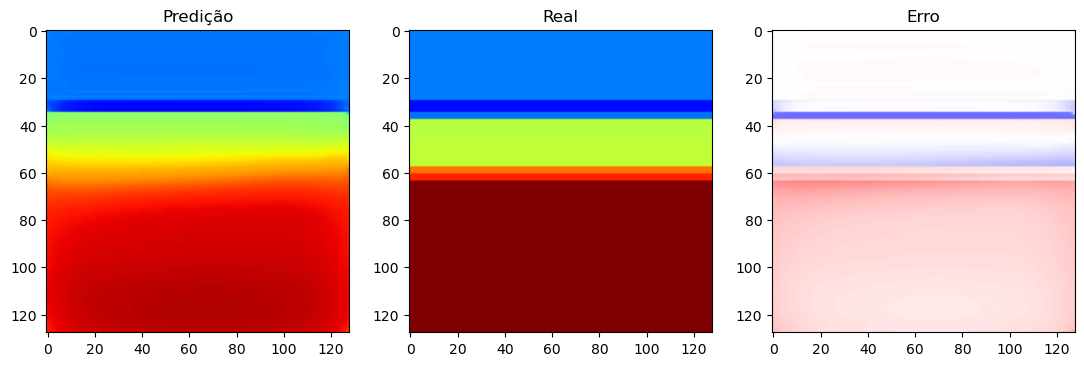

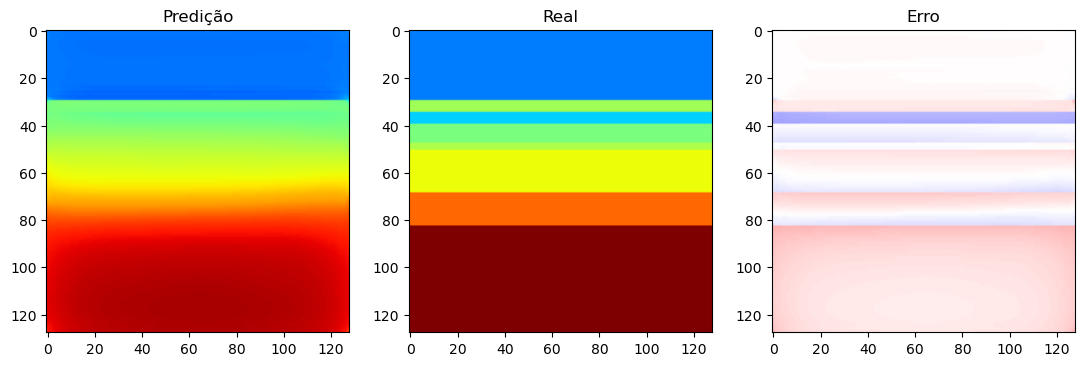

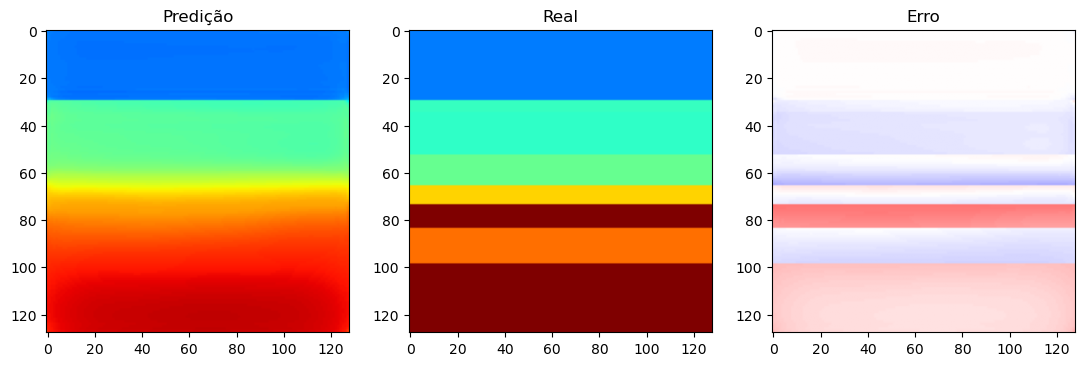

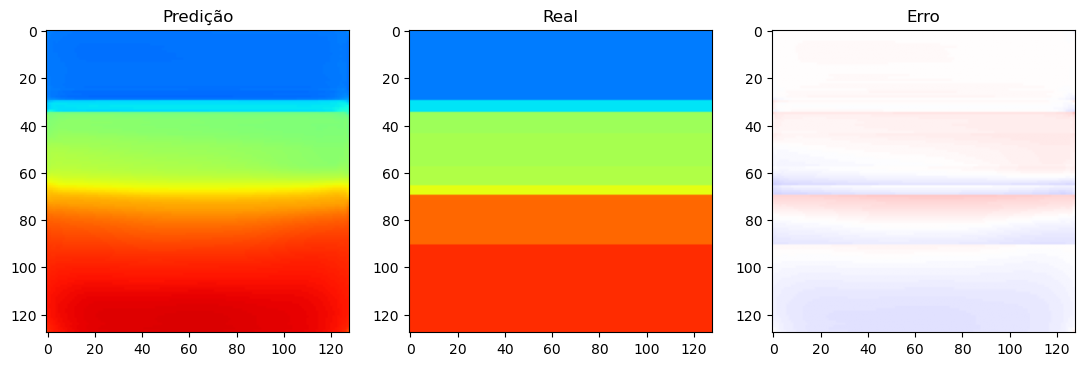

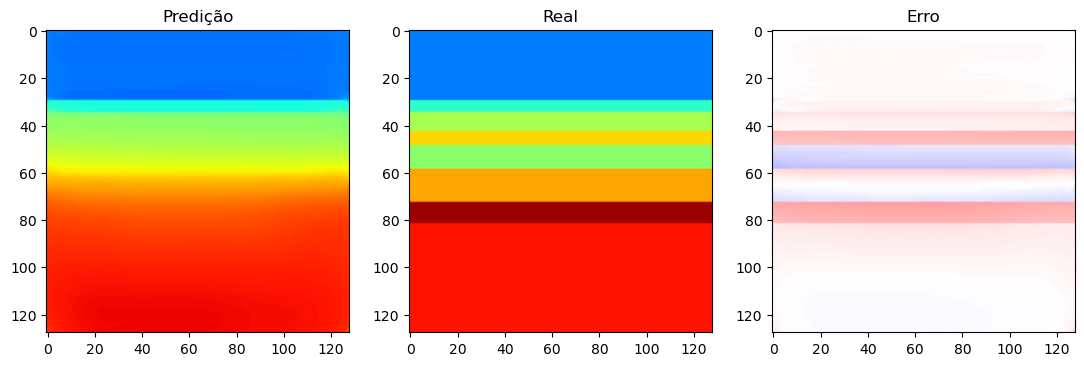

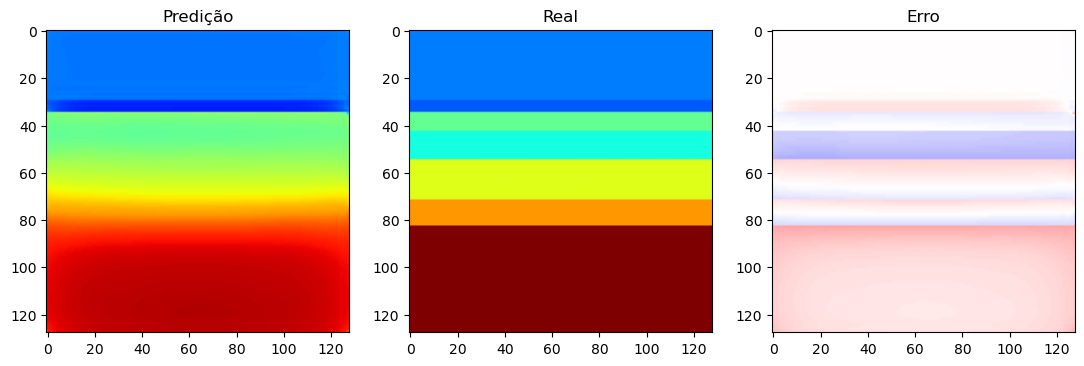

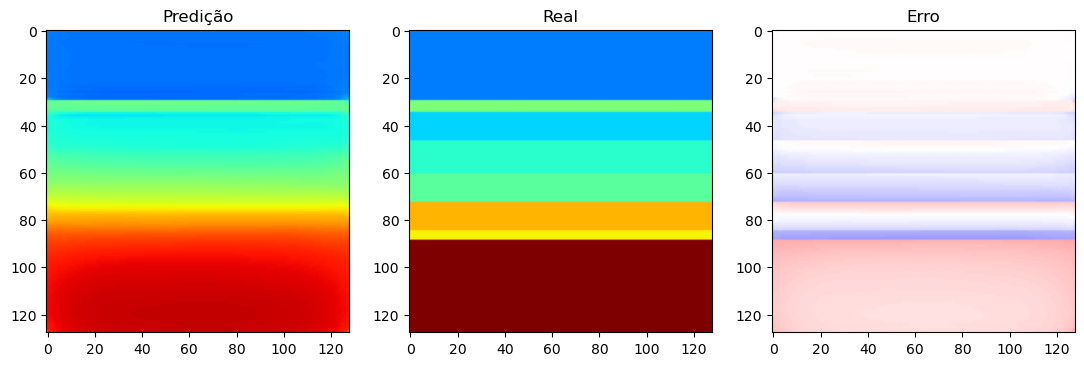

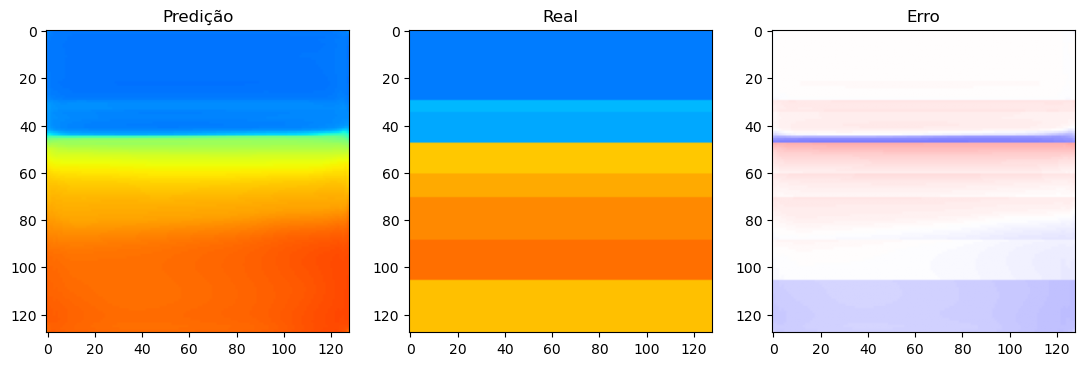

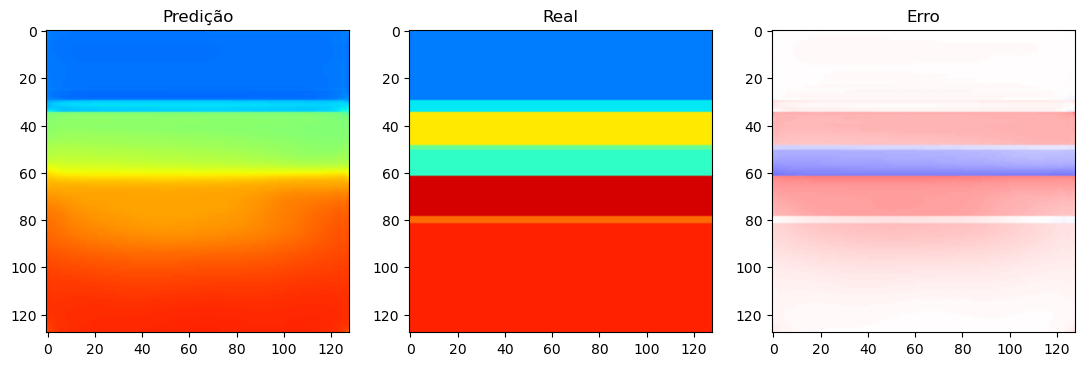

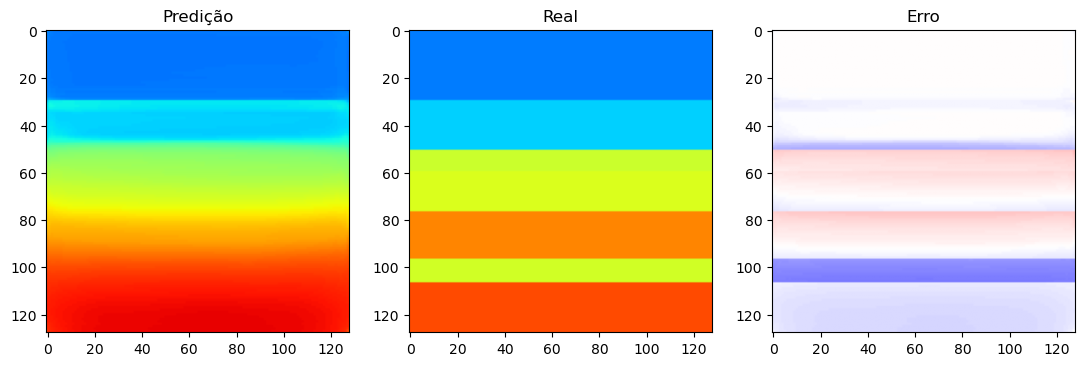

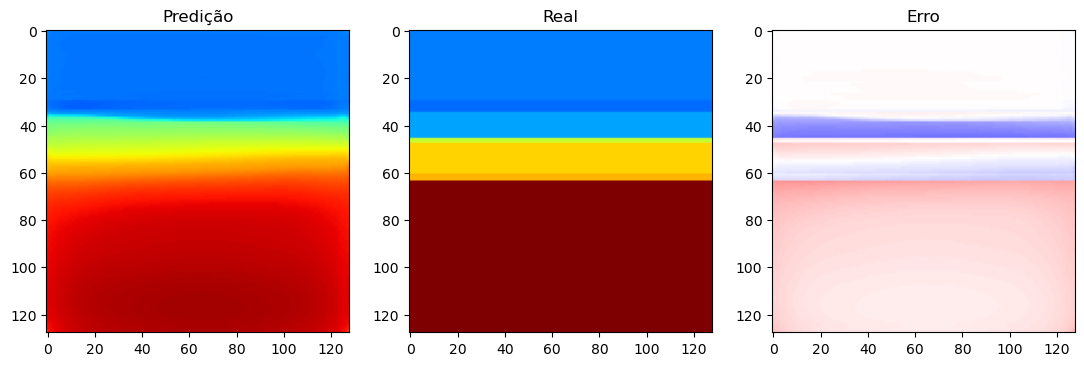

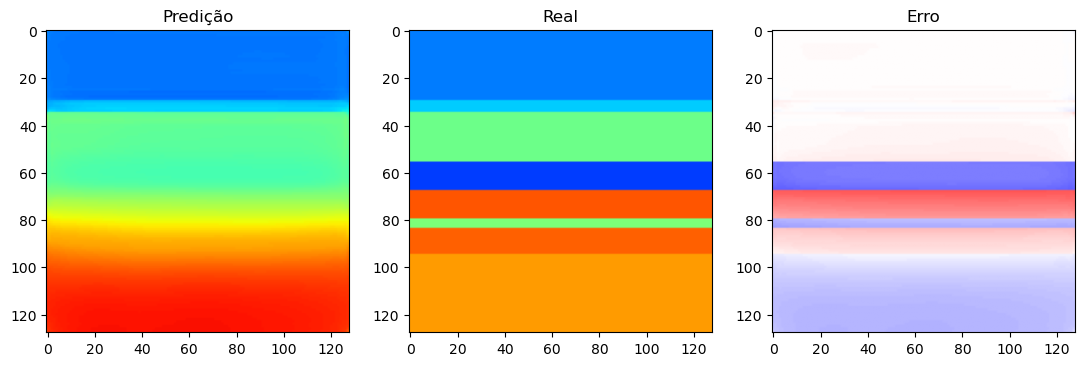

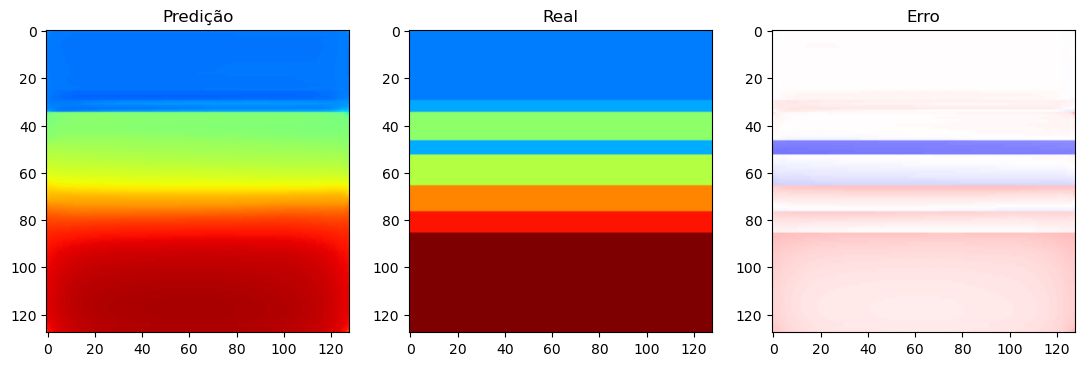

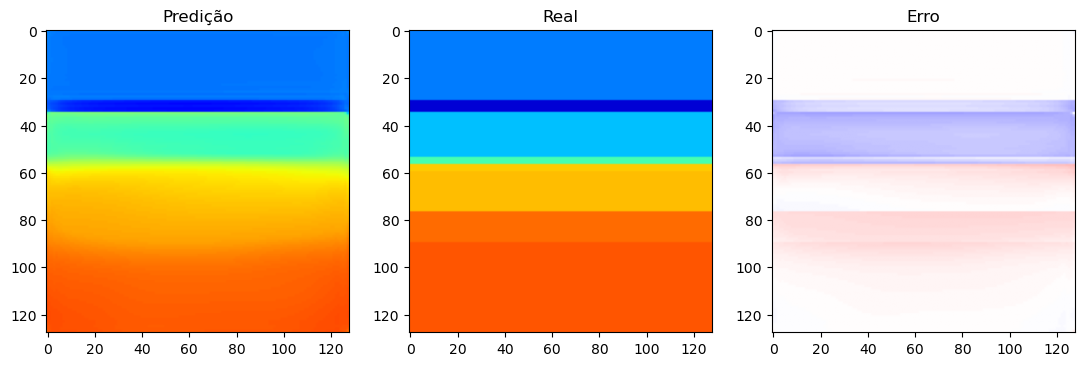

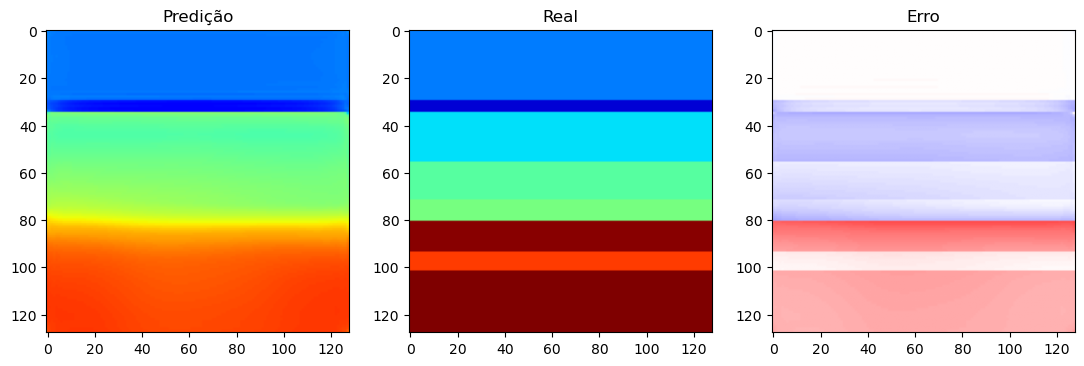

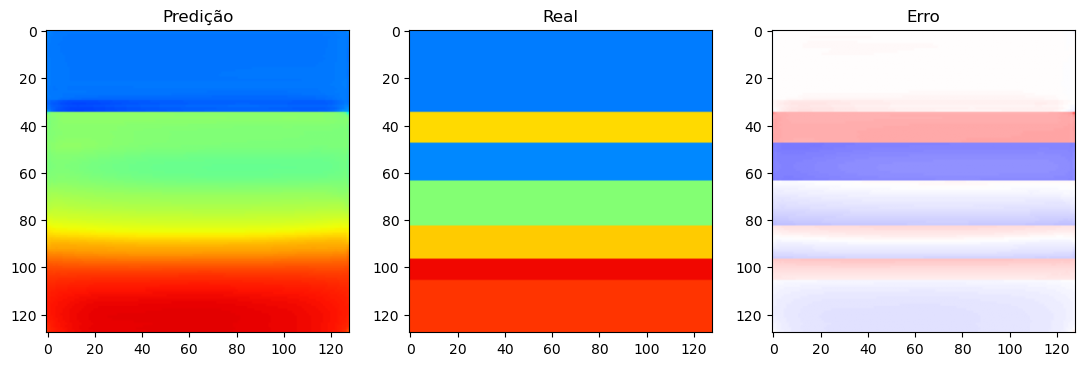

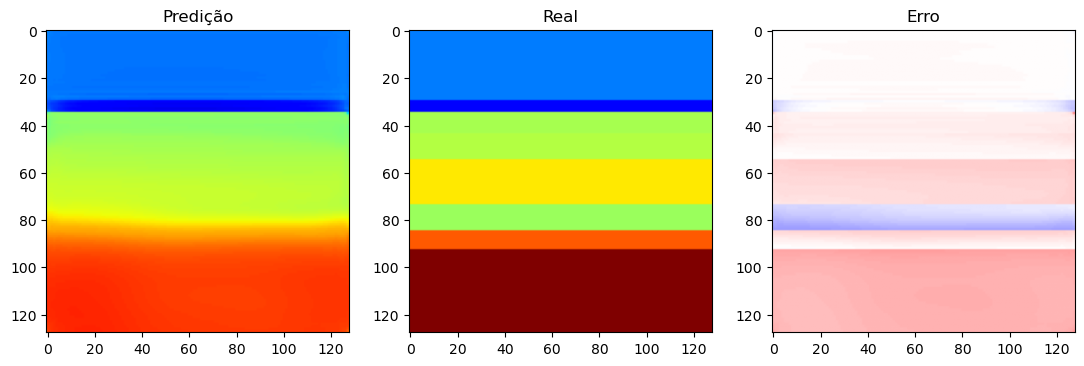

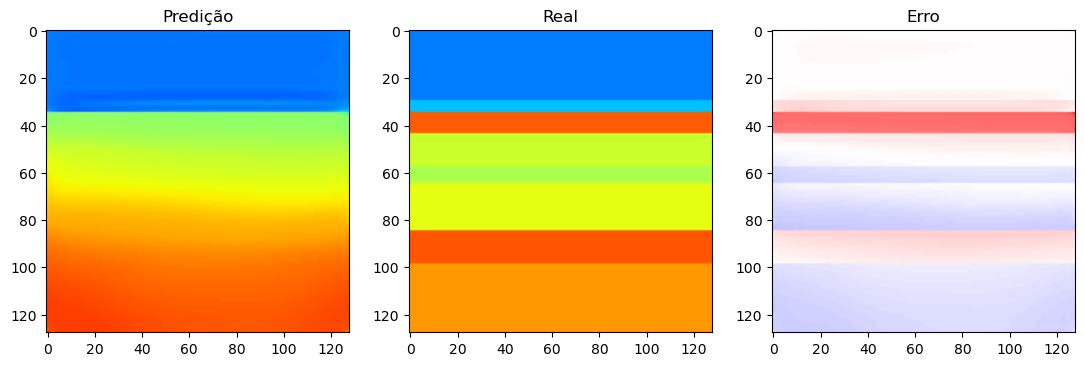

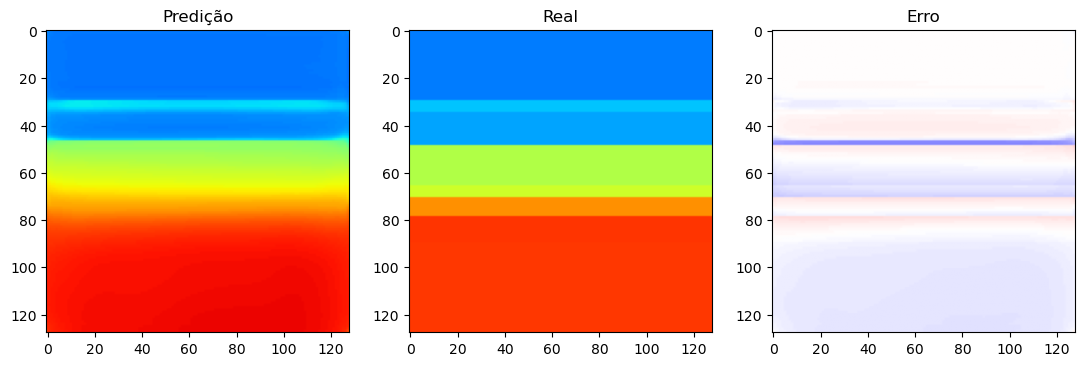

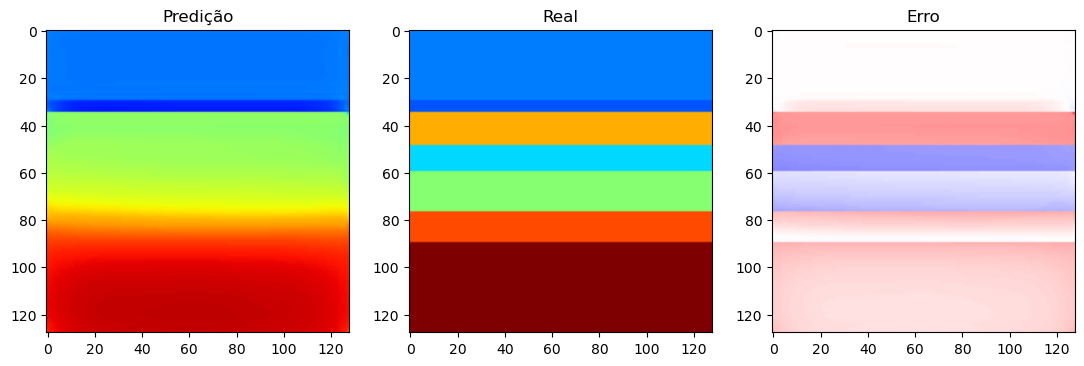

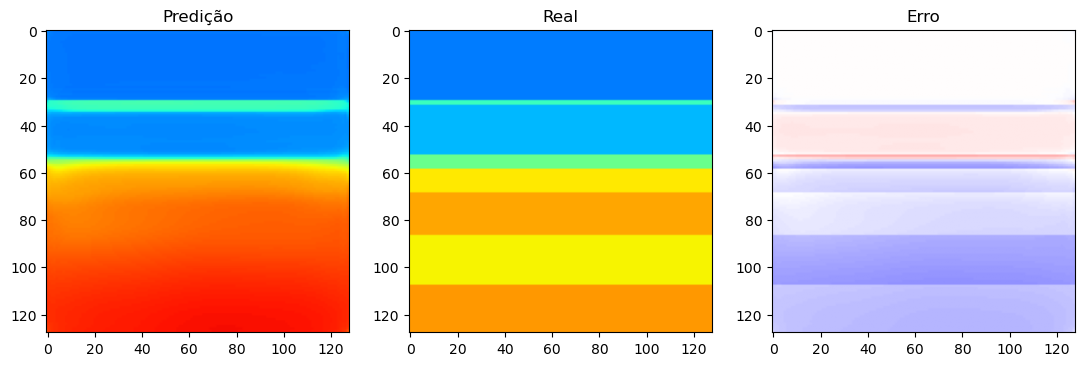

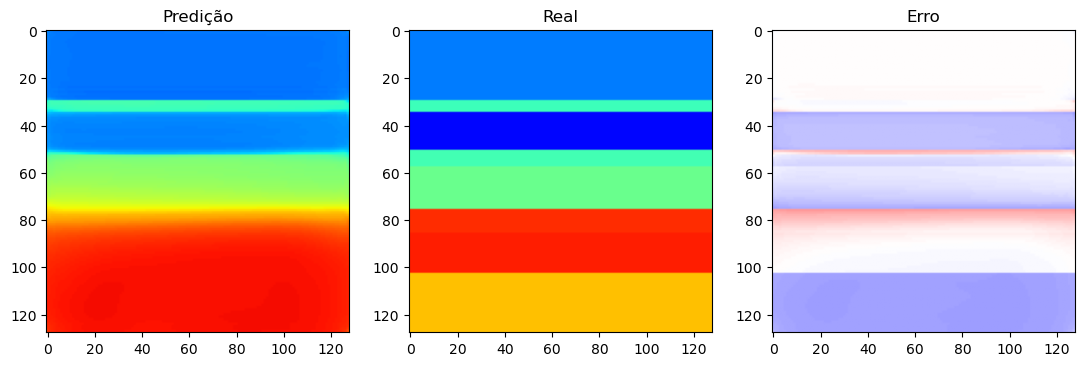

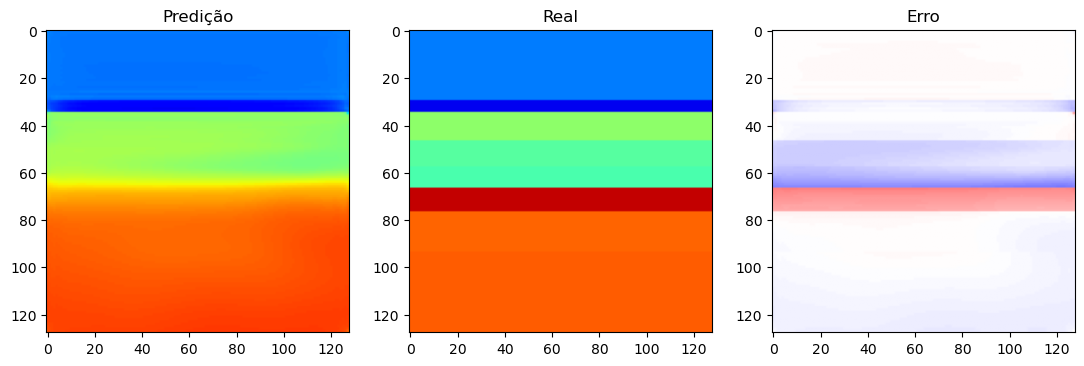

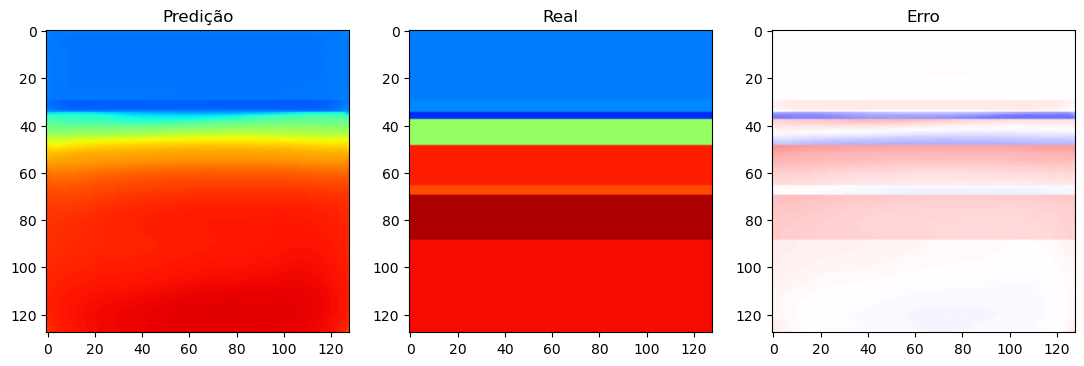

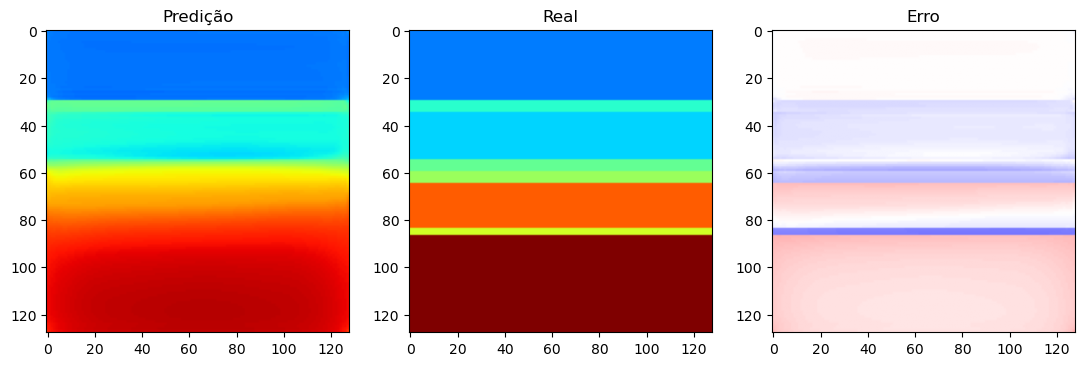

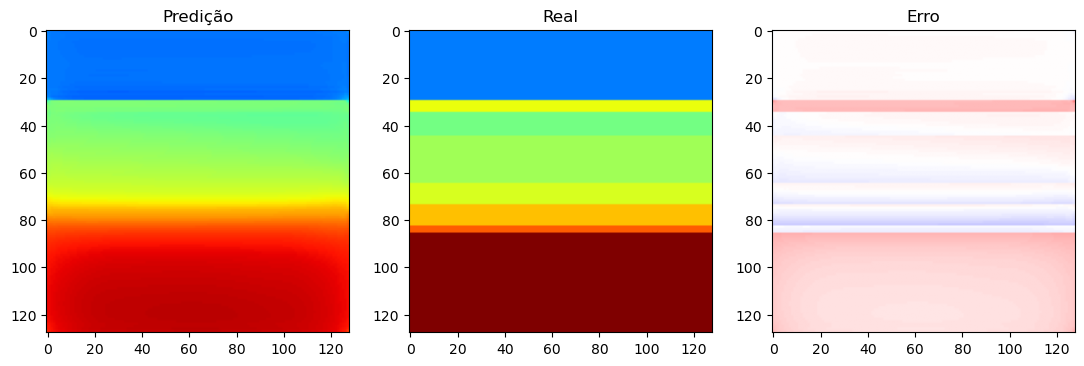

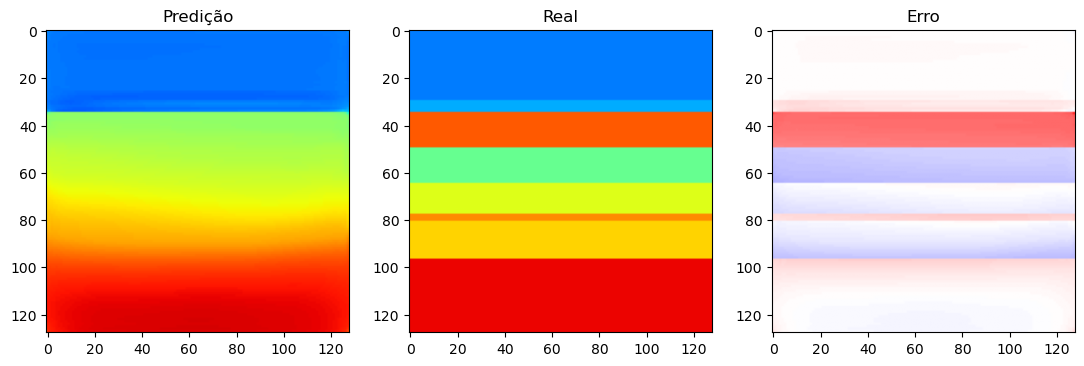

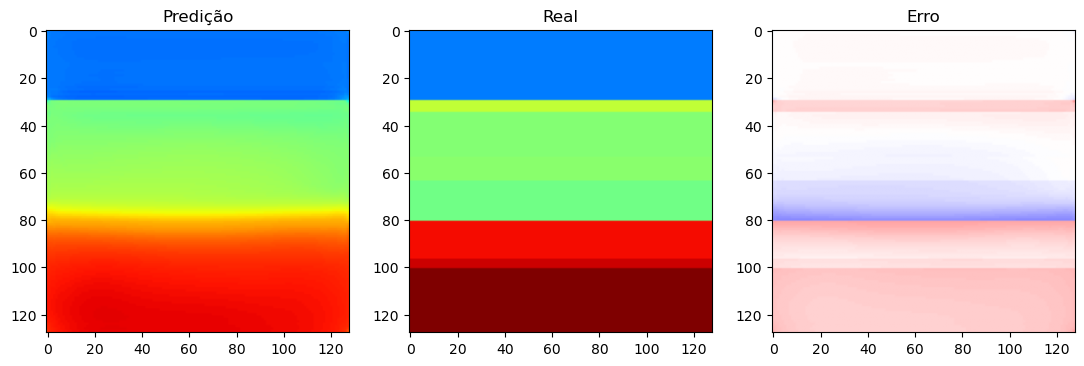

In [28]:
model.load_state_dict(torch.load("model_teste01.pth"))
model.eval()
pred = model(torch.tensor(x_test, dtype=torch.float32,device=device))
pred_cpu=pred.detach().cpu().numpy()

for i in range(len(x_test)):
    n_image = i#np.random.randint(0,len(pred))
    fig = plt.figure(figsize=(32,8))
    gs = fig.add_gridspec(1, 7)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])

    ax1.imshow(pred_cpu[n_image,0,:,:],cmap="jet",vmin=0,vmax=1)
    ax1.set_title('Predição')
    ax2.imshow(y_test[n_image,0,:,:],cmap="jet",vmin=0,vmax=1)
    ax2.set_title('Real')
    ax3.imshow(y_test[n_image,0,:,:]-pred_cpu[n_image,0,:,:], cmap="seismic",vmin=-1,vmax=1)
    ax3.set_title('Erro')
    fig = plt.gcf()
    plt.show()